# Loan Application Analysis

## Project Description
This project analyzes a dataset of loan applications to understand customer profiles, evaluate risk factors, and predict the likelihood of loan defaults. The dataset contains information such as Customer ID, Age, Income, Loan Amount, Credit Score, Loan Term, and Default Status. The analysis includes Exploratory Data Analysis (EDA), statistical summaries, visualizations, and predictive modeling to assist banks in making informed lending decisions.


## Objectives
- **Explore the dataset:** Understand distributions, summary statistics, and relationships between features.  
- **Analyze risk factors:** Identify which customer attributes (e.g., income, credit score, loan amount) influence default.  
- **Visualize data:** Use plots and charts to illustrate patterns, outliers, and trends.  
- **Predict defaults:** Build machine learning models to predict the probability of a customer defaulting.  
- **Provide actionable insights:** Help banks improve credit risk assessment and decision-making.

## Dataset Fields
- `Customer_ID` – Unique identifier for each customer  
- `Age` – Customer's age  
- `Income` – Customer's monthly or annual income  
- `Loan_Amount` – Amount of loan applied for  
- `Credit_Score` – Creditworthiness score  
- `Loan_Term` – Duration of loan in months  
- `Default_Status` – Target variable: Yes if defaulted, No otherwise

## Tools & Technologies
- Python (pandas, numpy, matplotlib, seaborn, scikit-learn)  
- Jupyter Notebook / IDE for analysis  
- CSV dataset (`loan_applications.csv`)


# Step 1 : Import required libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2 : Load Dataset 

In [4]:
data = pd.read_csv('loan_applications.csv')
print(data)

      Customer_ID  Age  Income  Loan_Amount  Credit_Score  Loan_Term  \
0          100000   59   77767        15618           804         24   
1          100001   49   48054        41561           543         60   
2          100002   35   95319        12373           773         48   
3          100003   63  122789        40281           681         12   
4          100004   28   65397        25187           402         36   
...           ...  ...     ...          ...           ...        ...   
4995       104995   53   93173        34742           696         12   
4996       104996   52   41225        12758           701         60   
4997       104997   49  131266        28437           573         60   
4998       104998   41   46739        24585           438         12   
4999       104999   41   67708        38223           402         24   

     Default_Status  
0                No  
1                No  
2                No  
3                No  
4                No  
...

# Step 3 : Central Tendency & Dispersion

## A. Find the Mean, median, mode 

In [10]:
income_mean = data['Income'].mean()
print(f"\nIncome Mean: {income_mean}")


Income Mean: 84685.349


In [11]:
income_median = data['Income'].median()
print(f"Income Median: {income_median}")

Income Median: 85484.5


In [15]:
income_mode = data['Income'].mode()[0]  
print(f"Income Mode : ", {income_mode})

Income Mode :  {np.int64(122828)}


## B. Range, Variance, Standard Deviation of Loan_Amount

In [18]:
loan_range = data['Loan_Amount'].max() - data['Loan_Amount'].min()
print(f"\nLoan Amount Range: {loan_range}")


Loan Amount Range: 44997


In [23]:
loan_variance = data['Loan_Amount'].var()
print(f"Loan Amount variance : ",loan_variance)

Loan Amount variance :  168475480.97249514


In [24]:
loan_std = data['Loan_Amount'].std()
print(f"Loan Amount Standard Deviation: {loan_std}")

Loan Amount Standard Deviation: 12979.810513736136


# Step 4 : Probability & Events

### a. Probability of loan default

In [25]:
prob_default = data['Default_Status'].value_counts(normalize=True).get('Yes', 0)
print(f"\nProbability of Loan Default: {prob_default}")


Probability of Loan Default: 0.4116


### b. Contingency Table: Default_Status vs Credit_Score (categorized)

In [28]:
bins = [0, 599, 699, 799, 850]
labels = ['<600', '600-699', '700-799', '800+']
data['Credit_Score_Range'] = pd.cut(data['Credit_Score'], bins=bins, labels=labels)

contingency_table = pd.crosstab(data['Default_Status'], data['Credit_Score_Range'])
print("\nContingency Table:\n", contingency_table)


Contingency Table:
 Credit_Score_Range  <600  600-699  700-799  800+
Default_Status                                  
No                  1348      558      662   374
Yes                 1427      319      220    92


### c. Conditional Probability: P(Default | Credit_Score < 600)

In [33]:
low_score_defaults = data[(data['Credit_Score'] < 600) & (data['Default_Status'] == 'Yes')].shape[0]
low_score_total = data[data['Credit_Score'] < 600].shape[0]

conditional_prob = low_score_defaults / low_score_total if low_score_total > 0 else 0
print(f"\nP(Default | Credit_Score < 600): {conditional_prob}")


P(Default | Credit_Score < 600): 0.5142342342342342


# Step 5 : Distributions & Visualization

### a. Histogram of Credit_Score with Gaussian curve

<Axes: xlabel='Credit_Score', ylabel='Density'>

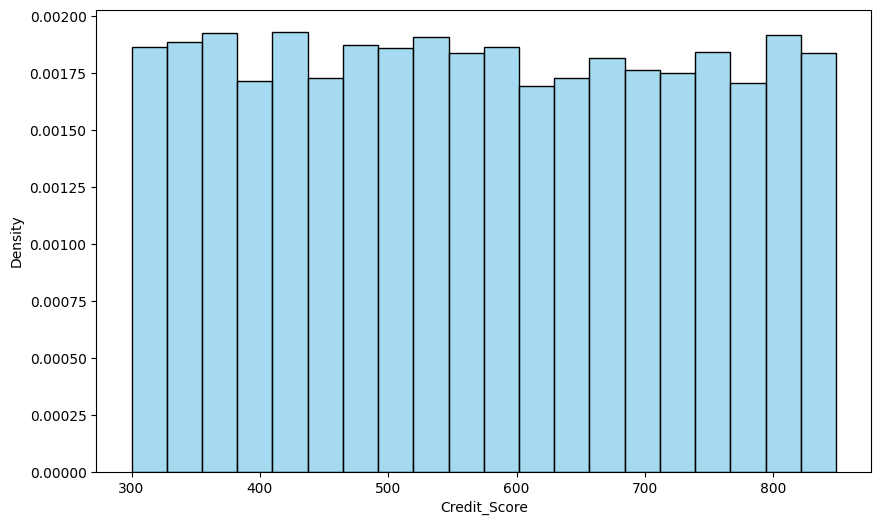

In [54]:
plt.figure(figsize=(10,6))
sns.histplot(data['Credit_Score'], bins=20, stat='density', color='skyblue', edgecolor='black', kde=False)


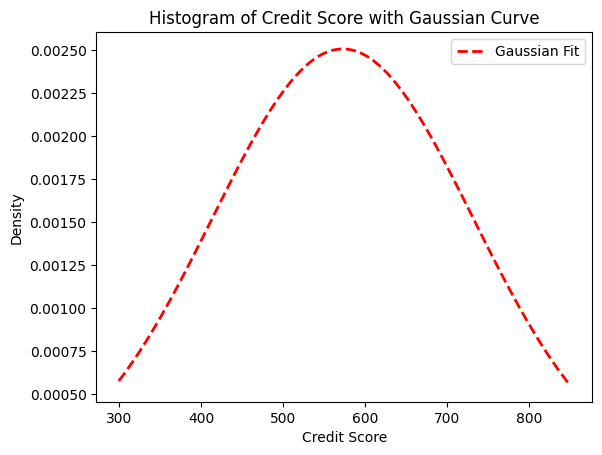

In [55]:
from scipy.stats import norm
mu, sigma = norm.fit(data['Credit_Score'])
x = np.linspace(data['Credit_Score'].min(), data['Credit_Score'].max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r--', linewidth=2, label='Gaussian Fit')
plt.title("Histogram of Credit Score with Gaussian Curve")
plt.xlabel("Credit Score")
plt.ylabel("Density")
plt.legend()
plt.show()


### Insights
> The histogram shows the distribution of customers' credit scores. \
> The Gaussian curve shows the approximate normality. \
> If the bars closely follow the red dashed curve, credit scores are roughly normally distributed. \
> Any skew or peaks can indicate concentration of credit scores in specific ranges.


### b. Skewness and Kurtosis of Loan_Amount

In [36]:
loan_skewness = data['Loan_Amount'].skew()
loan_kurtosis = data['Loan_Amount'].kurtosis()

print(f"\nLoan Amount Skewness: {loan_skewness}")
print(f"Loan Amount Kurtosis: {loan_kurtosis}")


Loan Amount Skewness: 0.018866417439715805
Loan Amount Kurtosis: -1.1920624550769308


### c. Q-Q Plot for Income

In [38]:
import statsmodels.api as sm

<Figure size 800x600 with 0 Axes>

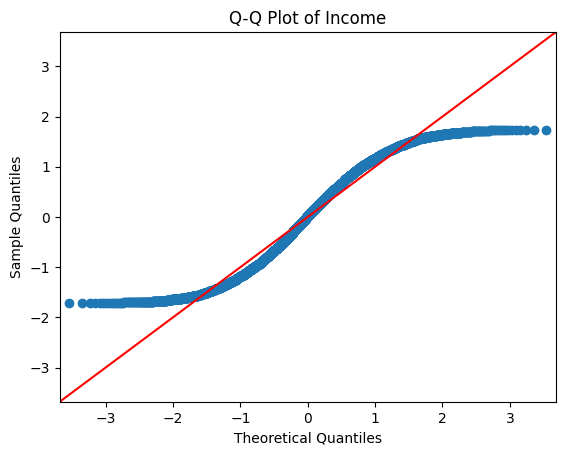

In [63]:
plt.figure(figsize=(8,6))
sm.qqplot(data['Income'], line='45', fit=True)
plt.title("Q-Q Plot of Income")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

> Q-Q plot compares the distribution of Income to a normal distribution. \
> If points lie roughly on the 45-degree line, Income is approximately normally distributed. \
> Deviations at the ends indicate outliers or heavy tails. 

# Step 6 : Linear Algebra Application

In [43]:
from numpy.linalg import norm

### Take first 5 customers' [Income, Loan_Amount] as vectors

In [50]:
vectors = data[['Income', 'Loan_Amount']].head(5).to_numpy()
print("\nFirst 5 Customer Vectors:\n", vectors)


First 5 Customer Vectors:
 [[ 77767  15618]
 [ 48054  41561]
 [ 95319  12373]
 [122789  40281]
 [ 65397  25187]]


### a. Dot product between first two customers

In [46]:
dot_product = np.dot(vectors[0], vectors[1])
print(f"\nDot Product between Customer 1 and 2: {dot_product}")


Dot Product between Customer 1 and 2: 4386115116


### b. Norm 2 of the first customer's vector

In [51]:
norm_customer1 = norm(vectors[0]) 
print(f"Norm 2 of Customer 1 Vector: {norm_customer1}")

Norm 2 of Customer 1 Vector: 79319.78449920297


### c. Angle between first two customer vectors

In [52]:
# formula: cos(theta) = (v1 . v2) / (||v1|| * ||v2||)
cos_theta = dot_product / (norm(vectors[0]) * norm(vectors[1]))
angle_radians = np.arccos(np.clip(cos_theta, -1.0, 1.0))
angle_degrees = np.degrees(angle_radians) 
print(f"Angle between Customer 1 and 2 Vectors (degrees): {angle_degrees}")

Angle between Customer 1 and 2 Vectors (degrees): 29.500221463651993


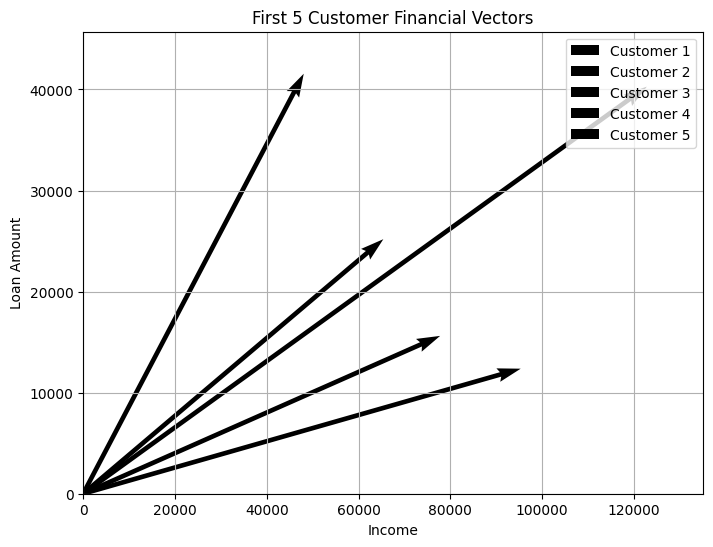

In [64]:

plt.figure(figsize=(8,6))
origin = [0,0]
for i, vec in enumerate(vectors):
    plt.quiver(*origin, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, label=f'Customer {i+1}')

plt.xlim(0, max(vectors[:,0])*1.1)
plt.ylim(0, max(vectors[:,1])*1.1)
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.title("First 5 Customer Financial Vectors")
plt.legend()
plt.grid(True)
plt.show()


### Insight:
> Each arrow = customer vector (Income, Loan Amount) \
> Length shows magnitude, angle shows similarity \
> Helps identify similar/different financial profiles 